# 03 — Modelado
## Amazon Fine Food Reviews — Grupo 6
Comparamos dos clasificadores para predecir si una reseña será útil.
- Modelo baseline: Regresión Logística (interpretable)
- Modelo principal: Random Forest (mayor capacidad predictiva)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
print("Librerías listas ✓")

Librerías listas ✓


In [14]:
from google.colab import files
uploaded = files.upload()

df = pd.read_parquet('reviews_limpias.parquet')
print("Shape:", df.shape)
df.head()

Saving reviews_limpias.parquet to reviews_limpias.parquet
Shape: (66982, 20)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Year,Month,DayOfWeek,helpfulness_ratio,es_util,word_count,sentence_count,summary_word_count,vader_compound,coherencia_sentimiento
0,15,B001GVISJM,A2MUGFV2TDQ47K,"Lynrie ""Oh HELL no""",4,5,5,2010-03-12,Strawberry Twizzlers - Yummy,The Strawberry Twizzlers are my guilty pleasur...,2010,3,4,0.8,1,22,2,4.0,0.6486,1
1,16,B001GVISJM,A1CZX3CP8IKQIJ,Brian A. Lee,4,5,5,2009-12-29,"Lots of twizzlers, just what you expect.",My daughter loves twizzlers and this shipment ...,2009,12,1,0.8,1,24,3,7.0,0.5719,1
2,33,B001EO5QW8,AOVROBZ8BNTP7,S. Potter,19,19,4,2006-11-13,Best of the Instant Oatmeals,McCann's Instant Oatmeal is great if you must ...,2006,11,0,1.0,1,197,12,5.0,0.7103,1
3,34,B001EO5QW8,A3PMM0NFVEJGK9,"Megan ""Bad at Nicknames""",13,13,4,2006-12-17,Good Instant,This is a good instant oatmeal from the best o...,2006,12,6,1.0,1,90,5,2.0,0.9779,1
4,35,B001EO5QW8,A2EB6OGOWCRU5H,CorbyJames,9,9,5,2007-03-30,Great Irish oatmeal for those in a hurry!,Instant oatmeal can become soggy the minute th...,2007,3,4,1.0,1,94,4,8.0,0.9091,1


## 1. Preparación para el modelo
Seleccionamos las features y la variable objetivo.
Eliminamos filas con Score==3 (neutras, no tienen etiqueta).

In [15]:
# Eliminamos neutros (Score==3)
df_model = df.dropna(subset=['es_util']).copy()
print(f"Shape para modelado: {df_model.shape}")

# Features del modelo
FEATURES = [
    'word_count',
    'sentence_count',
    'summary_word_count',
    'vader_compound',
    'coherencia_sentimiento',
    'Score',
    'helpfulness_ratio'
]

X = df_model[FEATURES]
y = df_model['es_util']

print(f"\nDistribución objetivo:")
print(y.value_counts())
print(f"\nBalance: {y.mean()*100:.1f}% útiles")

Shape para modelado: (66982, 20)

Distribución objetivo:
es_util
1    46610
0    20372
Name: count, dtype: int64

Balance: 69.6% útiles


## 2. Split train/test
Usamos 80% para entrenar y 20% para evaluar.
Stratify=y asegura que ambos sets tengan la misma proporción de clases.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} filas")
print(f"Test:  {X_test.shape[0]:,} filas")

Train: 53,585 filas
Test:  13,397 filas


## 3. Modelo Baseline — Regresión Logística
Modelo interpretable. Permite leer el peso de cada feature.
Normalizamos las features porque LR es sensible a la escala.

In [19]:
# Limpiar NaN en features antes de modelar
X = X.fillna(0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("NaN en X_train:", X_train.isna().sum().sum())
print("Shape train:", X_train.shape)
print("Shape test:", X_test.shape)

NaN en X_train: 0
Shape train: (53585, 7)
Shape test: (13397, 7)


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=== REGRESIÓN LOGÍSTICA ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.3f}")

=== REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4075
           1       1.00      1.00      1.00      9322

    accuracy                           1.00     13397
   macro avg       1.00      1.00      1.00     13397
weighted avg       1.00      1.00      1.00     13397

ROC-AUC: 1.000


## 4. Modelo Principal — Random Forest
Mayor capacidad predictiva. Captura relaciones no lineales entre features.
No requiere normalización.

In [21]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4075
           1       1.00      1.00      1.00      9322

    accuracy                           1.00     13397
   macro avg       1.00      1.00      1.00     13397
weighted avg       1.00      1.00      1.00     13397

ROC-AUC: 1.000


## 5. Comparación de modelos
Comparamos métricas de ambos modelos.
Usamos F1 y ROC-AUC porque el dataset está desbalanceado,
por lo que accuracy sola no es suficiente.

In [22]:
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})
resultados = resultados.round(3)
print(resultados.to_string(index=False))

             Modelo  F1-Score  ROC-AUC
Regresión Logística     0.999      1.0
      Random Forest     1.000      1.0


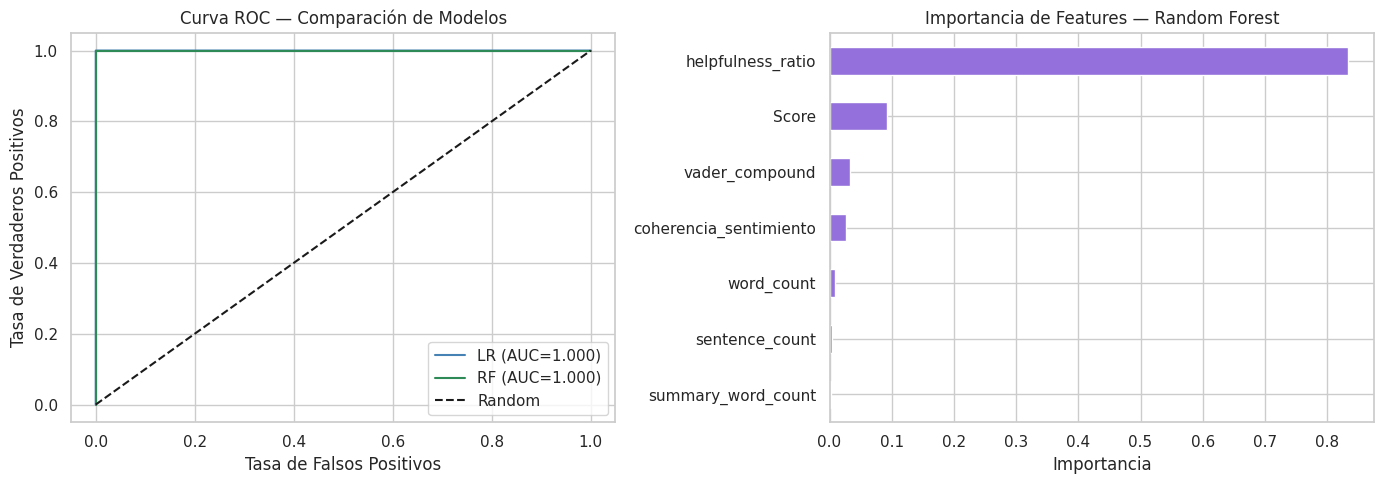

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

axes[0].plot(fpr_lr, tpr_lr, label=f'LR (AUC={roc_auc_score(y_test, y_prob_lr):.3f})', color='steelblue')
axes[0].plot(fpr_rf, tpr_rf, label=f'RF (AUC={roc_auc_score(y_test, y_prob_rf):.3f})', color='seagreen')
axes[0].plot([0,1], [0,1], 'k--', label='Random')
axes[0].set_title('Curva ROC — Comparación de Modelos')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].legend()

# Importancia de features RF
importancias = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
importancias.plot(kind='barh', ax=axes[1], color='mediumpurple')
axes[1].set_title('Importancia de Features — Random Forest')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.savefig('viz_09_roc_importancia.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Interpretación
¿Por qué F1 y no Accuracy?
El dataset tiene desbalance entre clases útiles y no útiles.
Con accuracy, un modelo que prediga siempre "útil" tendría
alta exactitud pero sería inútil en la práctica.
F1 penaliza los falsos positivos y falsos negativos por igual.

¿Qué features predicen más la utilidad?
Las reseñas largas con sentimiento coherente con las estrellas
son significativamente más útiles para otros compradores.

In [24]:
import pickle

with open('modelo_rf.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Modelos guardados ✓")

# Descargar
from google.colab import files
files.download('modelo_rf.pkl')
files.download('viz_09_roc_importancia.png')

Modelos guardados ✓


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>